In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(
    "../datasets/processed/ml_dataset.csv"
)

print("ML dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

ML dataset loaded successfully!
Shape: (100, 5)
   dividend_yield  dividend_growth  dividend_consistency  return_volatility  \
0            1.93             9.85                 90.91              36.16   
1            1.45            10.31                 90.91              36.16   
2            1.79            14.63                 90.91              36.16   
3            1.04             7.80                 90.91              36.16   
4            0.61             6.25                 90.91              36.16   

   total_return  
0         11.96  
1         47.56  
2         -5.00  
3         87.20  
4         81.36  


In [3]:
print(data.columns.tolist())


['dividend_yield', 'dividend_growth', 'dividend_consistency', 'return_volatility', 'total_return']


In [4]:
X = data[
    [
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "return_volatility"
    ]
]

y = data["total_return"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 4)
y shape: (100,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (80, 4)
X_test shape: (20, 4)


In [6]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [7]:
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [8]:
xgb_pred = xgb_model.predict(X_test)

print("First 10 predictions:")
print(xgb_pred[:10])

First 10 predictions:
[11.196326   6.8327036  3.824517  51.21387    4.2409453 14.801948
  6.2197523 15.665042  12.620337  37.849342 ]


In [9]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_mse = mean_squared_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("----------------")
print(f"MAE  : {xgb_mae:.4f}")
print(f"MSE  : {xgb_mse:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
----------------
MAE  : 15.1574
MSE  : 403.3640
RMSE : 20.0839
R²   : 0.1585


In [10]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance)

                Feature  Importance
0        dividend_yield    0.369330
1       dividend_growth    0.368466
3     return_volatility    0.262203
2  dividend_consistency    0.000000


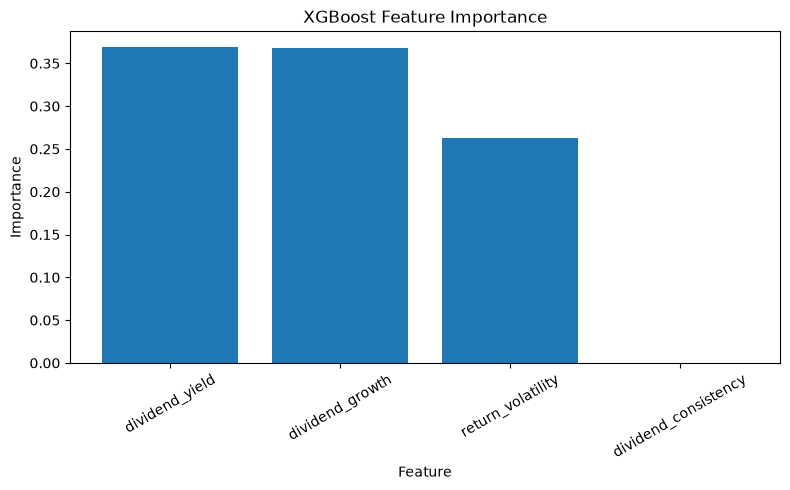

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
xgb_comparison = pd.DataFrame({
    "Actual_Return": y_test.values,
    "Predicted_Return": xgb_pred,
    "Residual": y_test.values - xgb_pred
})

print(
    xgb_comparison.head(10).to_string(index=False)
)

 Actual_Return  Predicted_Return   Residual
         29.36         11.196326  18.163674
         26.49          6.832704  19.657296
         19.75          3.824517  15.925483
         51.89         51.213871   0.676129
         41.98          4.240945  37.739055
          7.78         14.801948  -7.021948
          6.49          6.219752   0.270248
         15.65         15.665042  -0.015042
         14.89         12.620337   2.269663
         11.96         37.849342 -25.889342


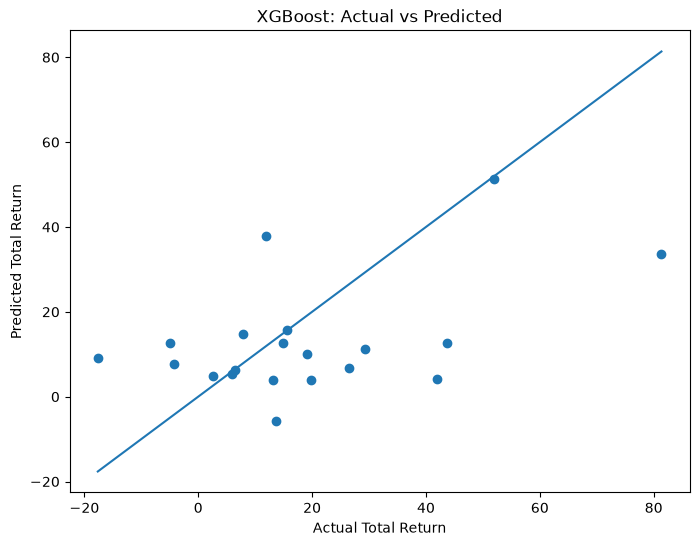

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    xgb_pred
)

min_value = min(y_test.min(), xgb_pred.min())
max_value = max(y_test.max(), xgb_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Total Return")
plt.ylabel("Predicted Total Return")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

In [14]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [xgb_mae],
    "MSE": [xgb_mse],
    "RMSE": [xgb_rmse],
    "R2": [xgb_r2]
})

xgb_results.to_csv(
    "../datasets/processed/day20_xgboost_results.csv",
    index=False
)

print("XGBoost results saved successfully!")

XGBoost results saved successfully!


In [15]:
xgb_importance.to_csv(
    "../datasets/processed/day20_xgboost_feature_importance.csv",
    index=False
)

print("XGBoost feature importance saved!")

XGBoost feature importance saved!


In [16]:
xgb_comparison.to_csv(
    "../datasets/processed/day20_xgboost_predictions.csv",
    index=False
)

print("XGBoost predictions saved!")

XGBoost predictions saved!


In [17]:
print("XGBoost Results")
print("----------------")
print(f"MAE  : {xgb_mae:.4f}")
print(f"MSE  : {xgb_mse:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

print("\nFeature Importance")
print(xgb_importance)

XGBoost Results
----------------
MAE  : 15.1574
MSE  : 403.3640
RMSE : 20.0839
R²   : 0.1585

Feature Importance
                Feature  Importance
0        dividend_yield    0.369330
1       dividend_growth    0.368466
3     return_volatility    0.262203
2  dividend_consistency    0.000000
